In [ ]:
# infer_rt.py
import torch
import torch.nn.functional as F
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from unet import UNet  # 你的UNet定义
# 如果没有train.py里的CONFIG，就手动给默认值

DEFAULT_CFG = dict(num_classes=1, bilinear=False, amp=True, mean=(0.5,), std=(0.5,))

def init_model(ckpt_path, device=None, cfg_override=None):
    device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    ckpt = torch.load(ckpt_path, map_location=device)
    cfg = DEFAULT_CFG.copy()
    cfg.update(ckpt.get("config", {}))
    if cfg_override:
        cfg.update(cfg_override)

    model = UNet(n_channels=1, n_classes=cfg["num_classes"], bilinear=cfg["bilinear"])
    model.to(device, memory_format=torch.channels_last)
    model.load_state_dict(ckpt["model"])
    model.eval()

    return model, cfg, device

def _normalize(img_np, mean, std):
    # img_np: [H, W] uint8 -> float32
    img = img_np.astype(np.float32) / 255.0
    return (img - mean[0]) / std[0]

def _denormalize(img_norm, mean, std):
    # 仅用于可视化原图时还原
    return np.clip((img_norm * std[0] + mean[0]) * 255.0, 0, 255).astype(np.uint8)

def predict(image_path, model, cfg, device, target_size=(576, 544),
            threshold=0.5, show=True, return_prob=False):
    """
    单张图推理
    - image_path: str
    - return_prob: True 返回[0,1]概率图；False 返回二值mask
    """
    # 1. 读图 & 归一化
    pil_img = Image.open(image_path).convert("L")
    orig_w, orig_h = pil_img.size
    img_np = np.array(pil_img)
    img_norm = _normalize(img_np, cfg["mean"], cfg["std"])

    # 2. 转 tensor & padding 到 target_size
    tensor = torch.from_numpy(img_norm).unsqueeze(0).unsqueeze(0).float()  # [1,1,H,W]
    H, W = tensor.shape[2:]
    pad_bottom = max(target_size[0] - H, 0)
    pad_right  = max(target_size[1] - W, 0)
    tensor = F.pad(tensor, (0, pad_right, 0, pad_bottom), value=0.0).to(device, memory_format=torch.channels_last)

    # 3. 推理
    with torch.inference_mode():
        use_amp = cfg.get("amp", True) and (device.type == "cuda")
        with torch.autocast(device_type=device.type if device.type != "mps" else "cpu", enabled=use_amp):
            logits = model(tensor)
            if cfg["num_classes"] == 1:
                prob = torch.sigmoid(logits)[0, 0]  # [H',W']
                pred_np = prob.cpu().numpy()
                if not return_prob:
                    pred_np = (pred_np >= threshold).astype(np.uint8) * 255
            else:
                prob = torch.softmax(logits, dim=1)[0]  # [C,H',W']
                pred_np = prob.argmax(0).cpu().numpy().astype(np.uint8)

    # 4. 去 padding（按原图尺寸裁剪）
    pred_np = pred_np[:H, :W]

    # 5. 可视化
    if show:
        fig, axes = plt.subplots(1, 2, figsize=(10, 5))
        axes[0].imshow(img_np, cmap="gray")
        axes[0].set_title("Original")
        axes[0].axis("off")

        if cfg["num_classes"] == 1:
            axes[1].imshow(pred_np, cmap="gray")
        else:
            axes[1].imshow(pred_np)  # 多类别直接用默认 colormap
        axes[1].set_title("Prediction")
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()

    return pred_np


In [5]:
ckpt = "outputs/checkpoints/best_model_v1.pth"
model, cfg, device = init_model(ckpt)

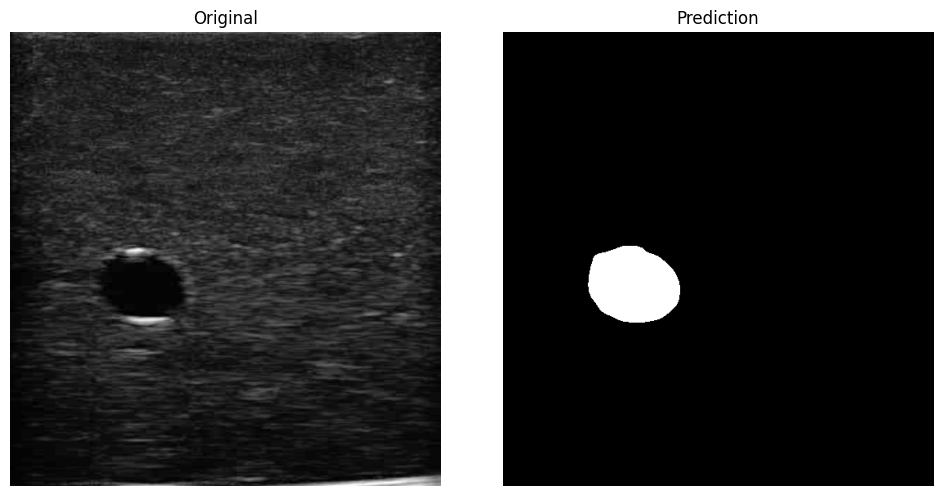

Prediction completed. Mask shape: (557, 528)
Mask type: uint8
[  0 255]


In [6]:
mask = predict("predict_test.png", model, cfg, device, show=True)


print("Prediction completed. Mask shape:", mask.shape)
# print the mask type
print("Mask type:", mask.dtype)
print(np.unique(mask))  # 打印mask中唯一值，检查是否有0和255

In [7]:
micropixel = 72.34590065828846 / 1000.0  # 1 pixel in mm

import numpy as np
import matplotlib.pyplot as plt

def measure_vessel(mask, mm_per_px, skin_row=0, show=True, img=None):
    """
    mask: 2D numpy array，0/1 或 0/255
    mm_per_px: 每个像素对应的毫米值
    skin_row: 皮肤表面的 y 坐标（默认0，即图像顶端）
    img: 原图(灰度)可选，用于可视化背景
    show: 是否用 matplotlib 画出两段距离
    """
    # 1. 规范成 bool
    mask_bool = mask > 0

    if mask_bool.sum() == 0:
        raise ValueError("mask 里没有前景像素，无法测量。")

    # 2. 如果有多个连通域，保留最大的那个
    # （若确定只有一个血管，可跳过这段）
    from scipy.ndimage import label
    lab, n_comp = label(mask_bool)
    if n_comp > 1:
        areas = [(lab == i).sum() for i in range(1, n_comp+1)]
        biggest = np.argmax(areas) + 1
        mask_bool = (lab == biggest)

    # 3. 取该血管的上下边界(y)
    ys, xs = np.where(mask_bool)
    top_y = ys.min()
    bottom_y = ys.max()

    # 4. 计算像素距离
    dist_skin_to_vessel_px = top_y - skin_row
    diameter_px = bottom_y - top_y + 1

    # 5. 转毫米
    dist_mm = dist_skin_to_vessel_px * mm_per_px
    diameter_mm = diameter_px * mm_per_px

    if show:
        fig, ax = plt.subplots(figsize=(6, 6))
        if img is not None:
            ax.imshow(img, cmap='gray')
        else:
            ax.imshow(mask_bool.astype(np.uint8)*255, cmap='gray')
        ax.set_title("Measurement")
        ax.axis("off")

        x_center = int(xs.mean())

        # 皮肤→血管
        ax.annotate(
            "", xy=(x_center, top_y), xytext=(x_center, skin_row),
            arrowprops=dict(arrowstyle="<->", color="red", lw=2)
        )
        ax.text(x_center+5, (top_y+skin_row)/2,
                f"{dist_mm:.2f} mm", color="red", va="center")

        # 血管直径
        ax.annotate(
            "", xy=(x_center, bottom_y), xytext=(x_center, top_y),
            arrowprops=dict(arrowstyle="<->", color="green", lw=2)
        )
        ax.text(x_center+5, (top_y+bottom_y)/2,
                f"{diameter_mm:.2f} mm", color="green", va="center")

        plt.tight_layout()
        plt.show()

    return {
        "dist_skin_to_vessel_px": dist_skin_to_vessel_px,
        "diameter_px": diameter_px,
        "dist_skin_to_vessel_mm": dist_mm,
        "diameter_mm": diameter_mm,
        "top_y": top_y,
        "bottom_y": bottom_y
    }


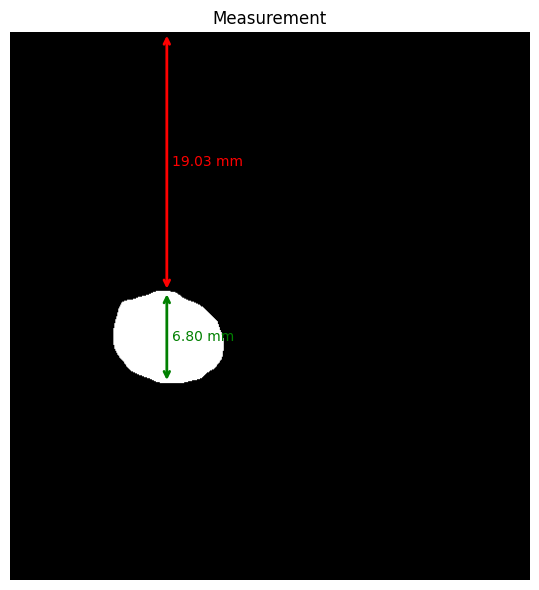

距离皮肤表面: 19.03 mm, 血管直径: 6.80 mm


In [6]:
result = measure_vessel(mask, mm_per_px=micropixel, skin_row=0, show=True, img=None)
print(f"距离皮肤表面: {result['dist_skin_to_vessel_mm']:.2f} mm, "
      f"血管直径: {result['diameter_mm']:.2f} mm")